In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
from codec import DataCodec

Починаємо тест на файлі: tests_samples\franko.txt

TESTING RLE
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 230,086 bytes
  Ratio: 1.999x
  Compress time: 54.49 ms
  Decompress time: 87.86 ms

TESTING LZW
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 46,158 bytes
  Ratio: 0.401x
  Compress time: 72.29 ms
  Decompress time: 29.76 ms

TESTING ARITHMETIC
--------------------------------------------------

RESULTS:
  Correct: PASS
  Size: 115,090 -> 60,419 bytes
  Ratio: 0.525x
  Compress time: 545.29 ms
  Decompress time: 590.21 ms


C:\Users\Даринка\AppData\Local\Temp\ipykernel_13020\2189306576.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='algorithm', y='ratio', data=df, ax=axes[0], palette='viridis')


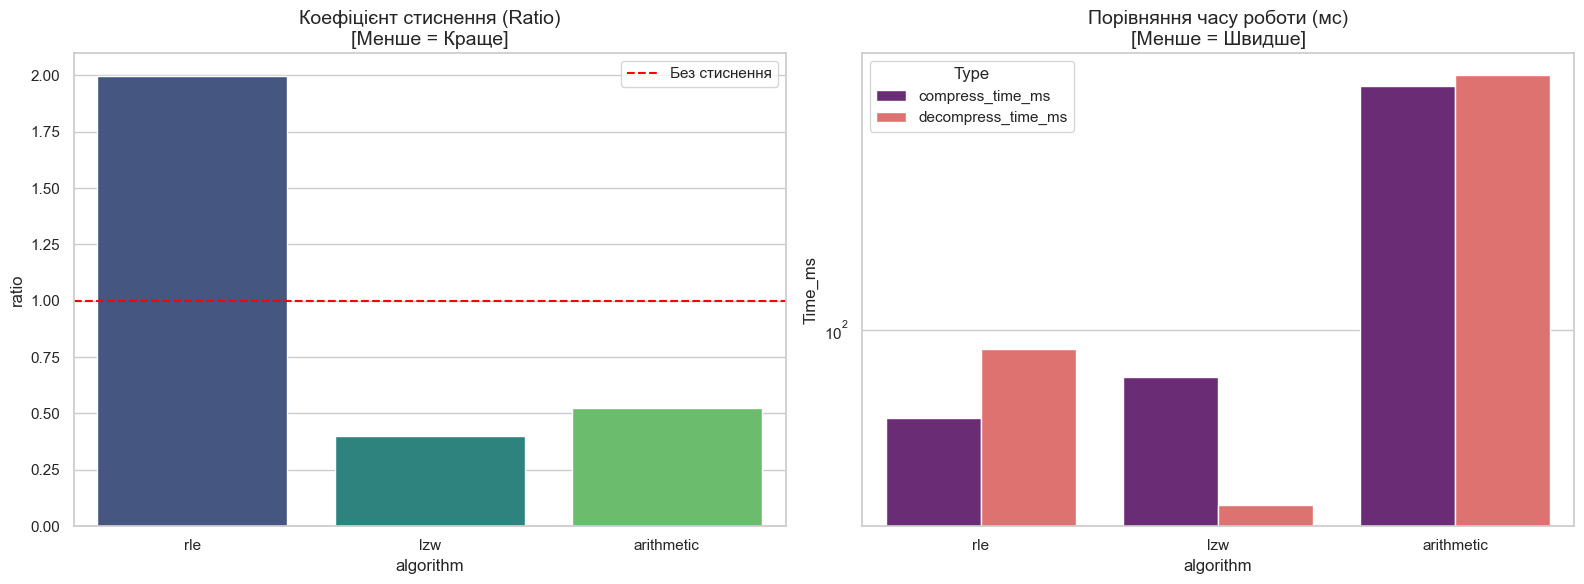

,algorithm,ratio,compress_time_ms,decompress_time_ms,is_valid
0,rle,1.999183,54.487228,87.856770,True
1,lzw,0.401060,72.293043,29.764175,True
2,arithmetic,0.524972,545.289516,590.205669,True


In [5]:
#Graphics style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

def run_benchmark(test_file_path):
    codec = DataCodec()

    # Список алгоритмів, які ми реально підключили в DataCodec
    algorithms = ['rle', 'lzw', 'arithmetic']

    results_list = []

    print(f"Починаємо тест на файлі: {test_file_path}")

    for algo in algorithms:
        try:
            res = codec.test_algorithm(test_file_path, algo)
            results_list.append(res)
        except Exception as e:
            print(f"Помилка в алгоритмі {algo}: {e}")

    return pd.DataFrame(results_list)

test_file = os.path.join("tests_samples", "franko.txt")

df = run_benchmark(test_file)

#Візуалізація
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Графік Коефіцієнта стиснення (Ratio)
# Чим нижче значення, тим краще стиснуто файл
# Додай це перед рядком sns.barplot...

sns.barplot(x='algorithm', y='ratio', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Коефіцієнт стиснення (Ratio)\n[Менше = Краще]', fontsize=14)
axes[0].axhline(1, color='red', linestyle='--', label='Без стиснення')
axes[0].legend()

# 2. Графік Часу (Compression vs Decompression)
df_time = df.melt(id_vars='algorithm', value_vars=['compress_time_ms', 'decompress_time_ms'],
                  var_name='Type', value_name='Time_ms')

sns.barplot(x='algorithm', y='Time_ms', hue='Type', data=df_time, ax=axes[1], palette='magma')
axes[1].set_title('Порівняння часу роботи (мс)\n[Менше = Швидше]', fontsize=14)
axes[1].set_yscale('log') # Логарифмічна шкала, якщо Arithmetic сильно повільніший за RLE

plt.tight_layout()
plt.show()

# Комірка 5: Висновок таблиці для точних цифр
display(df[['algorithm', 'ratio', 'compress_time_ms', 'decompress_time_ms', 'is_valid']])